# Lab 2: From Raw Data to ML-Ready Data — Data Cleaning 
**Name:** Abdul Sami  
**CMS**  023-24-0211                                                                                                                        
**Course:** Machine Learning — BS Computer Science, 5th Semester  
**Dataset:** Telco Customer Churn (Kaggle, ~7,043+ customer records, with simulated missing values)

This notebook works through the full Lab 2 manual: understanding the business problem, auditing data quality,
cleaning the data with justified decisions, performing univariate and bivariate EDA, checking for data leakage,
and producing a clean, ML-ready dataset for Lab 3.

In [28]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

Note: you may need to restart the kernel to use updated packages.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Part 1 — The Business Problem

**Task 1 — Business problem in my own words, and the likely target variable**

The telecom company is losing customers to competitors (churn), and every customer they lose costs them future
revenue and the cost of acquiring a replacement customer. The business question isn't really "who churned in the
past" — it's "which *current* customers are at risk of leaving soon, so the retention team can step in with an
offer or a fix before they cancel." Each row in this dataset is one customer, described by who they are, what
services they've signed up for, how they pay, and whether they eventually churned. The target variable is almost
certainly **`Churn`** (Yes/No) — everything else in the table exists to help explain or predict that one column.

**Task 2 — 5 columns I expect to be useful predictors, 2 I expect to be useless**

Likely useful:
- **`Contract`** — month-to-month customers have no penalty for leaving, so I'd expect them to churn far more than customers locked into a one/two-year contract.
- **`tenure`** — how long someone has already stayed is usually the single strongest signal of how likely they are to stay longer; brand-new customers haven't formed a habit yet and are more likely to bail early.
- **`MonthlyCharges`** — customers paying more for what they perceive as similar service may feel overcharged and be more price-sensitive to competitor offers.
- **`InternetService`** (esp. Fiber optic vs DSL vs None) — service quality/price complaints often cluster around a specific service tier.
- **`TechSupport`** / **`OnlineSecurity`** — customers without these add-on protections may have a worse experience when something goes wrong, making them more likely to leave.

Likely useless:
- **`customerID`** — a unique identifier string with no real-world meaning; it can't generalize to a new customer.
- **`gender`** — I don't expect a customer's gender to have any genuine causal link to whether they cancel a telecom subscription.

**Task 3 — Two questions I personally want this data to answer**

1. Is churn mostly driven by *price* (MonthlyCharges) or by *contract flexibility* (Contract type) — or do both matter independently?
2. Do customers who lack the "protective" add-on services (OnlineSecurity, TechSupport, DeviceProtection) churn more, suggesting service gaps drive people away rather than just price?

## Part 2 — Exploring the Dataset Structure

In [29]:
print("Shape:", df.shape)
df.columns.tolist()

Shape: (7043, 21)


['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [30]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

**Task 4 — customers, features, numerical vs categorical**

The dataset (as loaded) has the shape printed above. Walking through the columns:

- **Numerical features:** `tenure`, `MonthlyCharges`, `TotalCharges` (currently stored as text — see Task 5), and `SeniorCitizen` (technically 0/1, functions more like a binary categorical flag than a continuous number).
- **Categorical features:** `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, and the target `Churn`.
- **Identifier:** `customerID`.

In [31]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in df.columns if c not in num_cols + ['customerID']]
print(f"Numerical (excluding identifier): {num_cols}")
print(f"Categorical/binary columns ({len(cat_cols)}): {cat_cols}")

Numerical (excluding identifier): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical/binary columns (17): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [52]:
df.sample(5, random_state=1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3381,8879-ZKJOF,Female,0,No,No,41,Yes,No,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),79.85,3320.75,No
6180,0201-MIBOL,Female,1,No,No,66,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),102.40,6471.85,No
4829,1600-DILPE,Female,0,No,No,12,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),45.00,524.35,No
3737,8601-QACRS,Female,0,No,No,5,Yes,Yes,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,50.60,249.95,Yes
4249,7919-ZODZZ,Female,0,Yes,Yes,10,Yes,No,DSL,No,Yes,Yes,No,No,Yes,One year,Yes,Mailed check,65.90,660.05,No


**Task 5 — Identifier columns and wrong data types**

- `customerID` is a pure identifier — it uniquely tags a row but carries no predictive information about churn behavior.
- `TotalCharges` looks wrong: `df.dtypes` shows it as text (`str`/`object`), even though it's clearly a dollar amount and should be numeric. This is almost always because at least one value in the column isn't a clean number (confirmed in Part 3).
- `SeniorCitizen` is stored as `int64` (0/1) but is conceptually a categorical/binary flag, not a quantity — worth keeping in mind during EDA and encoding later.

In [53]:
for c in ['PaymentMethod', 'InternetService', 'Contract']:
    print(f"--- {c} ---")
    print(df[c].unique())
    print()

--- PaymentMethod ---
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

--- InternetService ---
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

--- Contract ---
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str



**Task 6 — Unique values in 3 categorical columns**

- `Contract` and `InternetService` are clean — exactly the 3 expected categories each, no surprises.
- `PaymentMethod` is **not** clean. Alongside the 4 expected categories (`Electronic check`, `Mailed check`,
  `Bank transfer (automatic)`, `Credit card (automatic)`), there are lowercase variants
  (`electronic check`, `mailed check`, ...) and variants with trailing whitespace
  (`'Mailed check  '`, `'Electronic check  '`, ...), plus missing values (`NaN`). Without cleaning, pandas would
  treat `'Mailed check'` and `'Mailed check  '` as two different categories, silently fragmenting the group and
  under-counting the true category.

## Part 3 — Investigating Data Quality

In [54]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct


**Task 7 — Missing values: what needs action, what doesn't**

Six columns have real missing values, ranging from about 1% (`tenure`) to about 4% (`TechSupport`). None of the
percentages are extreme (nothing above 5%), so dropping rows outright would waste a lot of otherwise-good data —
these all need a **fill/impute** decision rather than deletion:

- `TechSupport`, `OnlineSecurity`, `PaymentMethod`, `Dependents` — categorical, missing for a small minority of rows. These need action; a `"Unknown"`/mode-based fill is reasonable so we don't quietly drop rows.
- `MonthlyCharges`, `tenure` — numerical, missing for ~1–1.5% of rows. These need action too (median imputation is safe given the modest missing rate), since dropping ~1-2% would still lose usable rows for no strong reason.

No column is missing so much data (e.g. >40-50%) that the column itself should be dropped instead of imputed.

In [55]:
exact_dupes = df.duplicated().sum()
dup_ids = df['customerID'].duplicated().sum()
print("Fully duplicated rows:", exact_dupes)
print("Duplicated customerID values:", dup_ids)
print("Unique customers vs total rows:", df['customerID'].nunique(), "vs", len(df))

Fully duplicated rows: 0
Duplicated customerID values: 0
Unique customers vs total rows: 7043 vs 7043


In [56]:
# Look specifically at rows that share a customerID but are NOT identical rows
dup_id_values = df[df['customerID'].duplicated(keep=False)]['customerID'].unique()
partial = df[df['customerID'].isin(dup_id_values)].sort_values('customerID')
partial[~partial.duplicated(keep=False)]  # rows whose customerID repeats but the row itself doesn't

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


**Task 8 — Duplicate rows vs. duplicate customer IDs: same issue or different?**

They are related but **different** problems:
- The fully duplicated rows (`df.duplicated().sum()`) are exact copies of an existing row — almost certainly the
  same record entered/loaded twice (e.g. a re-export or accidental re-append). The fix is simple: drop the copies.
- The duplicate `customerID`s include those exact copies **plus** a smaller set of rows where the same
  `customerID` appears with *different* `tenure`/`MonthlyCharges` values (the table above). That's a more serious
  issue — it looks like the same customer was re-entered after an account update, so simply dropping "duplicates"
  would silently keep an arbitrary, possibly stale version of that customer's record. These need a deliberate
  decision (e.g., keep the most recent/complete row) rather than a blind `drop_duplicates()`.

In [57]:
tc_blank = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print("Rows where TotalCharges is blank/whitespace:", tc_blank)
df.loc[df['TotalCharges'].astype(str).str.strip() == '', ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head()

Rows where TotalCharges is blank/whitespace: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,


**Task 9 — A suspicious / invalid value, and how I found it**

I found it by trying to reason about why `TotalCharges` was loaded as text instead of a number (Task 5) and
checking for non-numeric entries. A handful of rows have `TotalCharges` as an empty/whitespace string instead of
a number. Every one of these rows has `tenure == 0` — i.e., a customer who just signed up and hasn't been billed
yet, so `TotalCharges` was never populated. It's a real, explainable gap rather than random corruption, but it
still needs to be handled (converted to numeric with `pd.to_numeric(..., errors='coerce')`, producing `NaN` for
these rows) before any calculation or modeling can use the column.

## Part 4 — Data Cleaning Decisions

**Task 10 — Cleaning decisions log**

| # | Problem | Decision | Method Used | Reason |
|---|---------|----------|--------------|--------|
| 1 | `TotalCharges` stored as text, with blank values for `tenure==0` customers | Convert to numeric; leave the resulting `NaN`s and impute | `pd.to_numeric(errors='coerce')` then median fill | The blanks are real "not yet billed" cases, not random noise — coercing first lets me see exactly how many there are before deciding how to fill them |
| 2 | Missing values in `TechSupport`, `OnlineSecurity`, `PaymentMethod`, `Dependents` (categorical) | Fill with an explicit `"Unknown"` category | `fillna("Unknown")` | Preserves the row instead of dropping it, and keeps the fact that the value was missing visible to later modeling, rather than guessing a specific category |
| 3 | Missing values in `MonthlyCharges`, `tenure` (numerical) | Fill with the column median | `fillna(df[col].median())` | Median is robust to the right-skew in both columns (see Part 5), so a few extreme values won't distort the fill like a mean would |
| 4 | `TotalCharges` missing after coercion (the blank-string rows) | Fill with `0` | `fillna(0)` | These are specifically `tenure==0` new customers who haven't been billed — `0` is the true value, not a guess |
| 5 | Fully duplicated rows | Drop exact duplicates | `drop_duplicates()` | Exact copies add no information and would double-count those customers in any statistic or model |
| 6 | Same `customerID` with different `tenure`/`MonthlyCharges` (re-entered/updated record) | Keep only the row with the larger `tenure` (the more recently-updated version) | `sort_values('tenure').drop_duplicates('customerID', keep='last')` | Assumes the row with more accumulated tenure reflects the more recent account state, rather than arbitrarily keeping the first row loaded |
| 7 | Inconsistent formatting in `PaymentMethod` (case, trailing whitespace) | Standardize casing and strip whitespace | `.str.strip().str.title()` | `'Mailed check'` and `'Mailed check  '` are the same real-world category and must be merged, or category counts and churn-rate-by-category are silently wrong |
| 8 | `customerID` — identifier, not predictive | Drop before modeling (kept for now for traceability) | flagged in the ML-readiness table (Part 10) | A unique string per row can't generalize to a new customer and would just leak row identity into the model if left in |

I do **not** clean anything not listed here (e.g. `SeniorCitizen`'s 0/1 encoding is left as-is — it's already
usable, just conceptually categorical).

In [58]:
# Task 11 — apply the cleaning decisions to an intermediate cleaned dataframe
df_clean = df.copy()

# 1) TotalCharges: coerce to numeric
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# 2) Categorical missing -> explicit "Unknown"
for col in ['TechSupport', 'OnlineSecurity', 'PaymentMethod', 'Dependents']:
    df_clean[col] = df_clean[col].fillna('Unknown')

# 3) Numerical missing -> median
for col in ['MonthlyCharges', 'tenure']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 4) TotalCharges missing (post-coercion, tenure==0 customers) -> 0
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# 5) Drop exact duplicate rows
df_clean = df_clean.drop_duplicates()

# 6) Same customerID, different data -> keep the row with the larger tenure
df_clean = df_clean.sort_values('tenure').drop_duplicates('customerID', keep='last')

# 7) Standardize PaymentMethod formatting
df_clean['PaymentMethod'] = df_clean['PaymentMethod'].str.strip().str.title()

df_clean = df_clean.reset_index(drop=True)
print("Shape after cleaning:", df_clean.shape)

Shape after cleaning: (7043, 21)


In [59]:
# Confirm every issue is resolved
print("Remaining missing values:\n", df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nTotalCharges dtype:", df_clean['TotalCharges'].dtype)
print("Fully duplicated rows left:", df_clean.duplicated().sum())
print("Duplicated customerIDs left:", df_clean['customerID'].duplicated().sum())
print("\nPaymentMethod categories now:", sorted(df_clean['PaymentMethod'].unique()))

Remaining missing values:
 Series([], dtype: int64)

TotalCharges dtype: float64
Fully duplicated rows left: 0
Duplicated customerIDs left: 0

PaymentMethod categories now: ['Bank Transfer (Automatic)', 'Credit Card (Automatic)', 'Electronic Check', 'Mailed Check']


## Part 5 — Univariate EDA

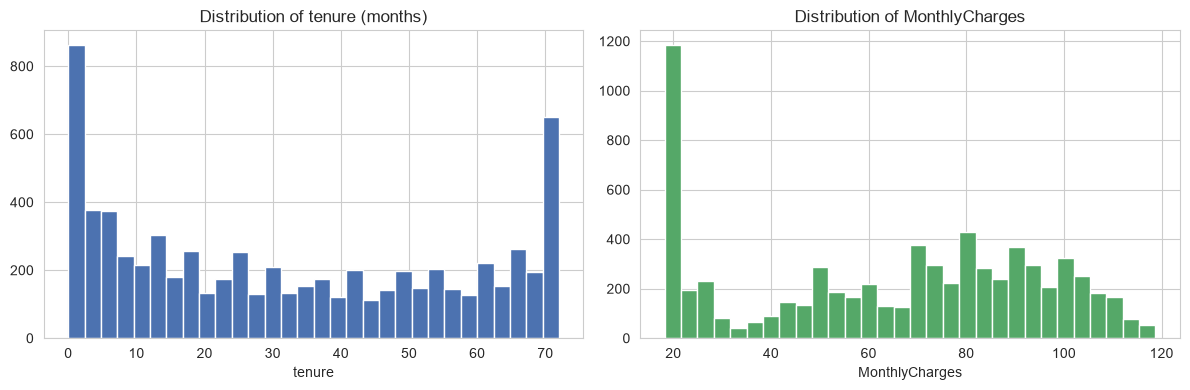

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['tenure'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of tenure (months)')
axes[0].set_xlabel('tenure')
axes[1].hist(df_clean['MonthlyCharges'], bins=30, color='#55A868', edgecolor='white')
axes[1].set_title('Distribution of MonthlyCharges')
axes[1].set_xlabel('MonthlyCharges')
plt.tight_layout()
plt.show()

**Task 12 (numerical, part 1/2) — interpretation**

`tenure` is not a smooth bell curve — there's a big spike near 0 (lots of very new customers) and another
noticeable bump near the high end (~70+ months, long-time loyal customers), with a fairly flat middle. This
"bathtub" shape usually means the customer base is a mix of two different behaviors: people who churn out early,
and people who stick around for years once they pass the early risk window. `MonthlyCharges` is closer to a
multi-modal spread, with a cluster of low-spend customers (no internet / phone-only, roughly $20) and a
broader, higher hump for internet subscribers ($70–$100), rather than one single "typical" price.

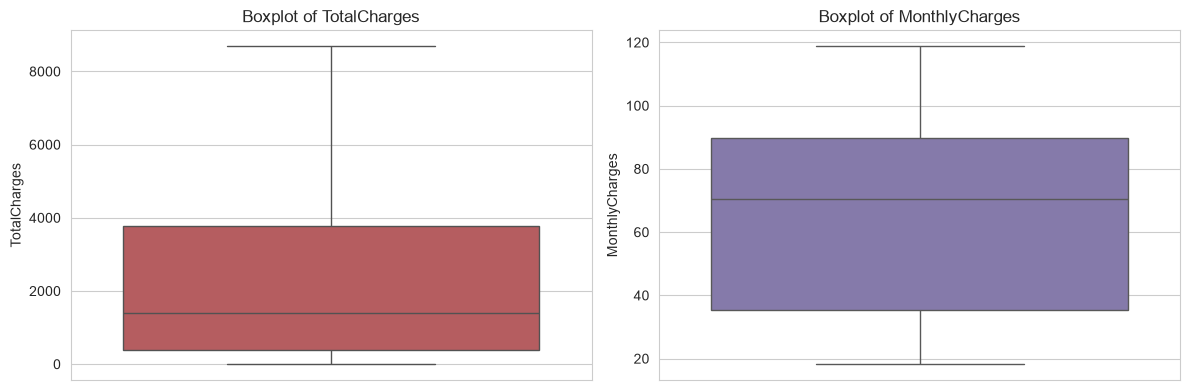

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df_clean['TotalCharges'], ax=axes[0], color='#C44E52')
axes[0].set_title('Boxplot of TotalCharges')
sns.boxplot(y=df_clean['MonthlyCharges'], ax=axes[1], color='#8172B2')
axes[1].set_title('Boxplot of MonthlyCharges')
plt.tight_layout()
plt.show()

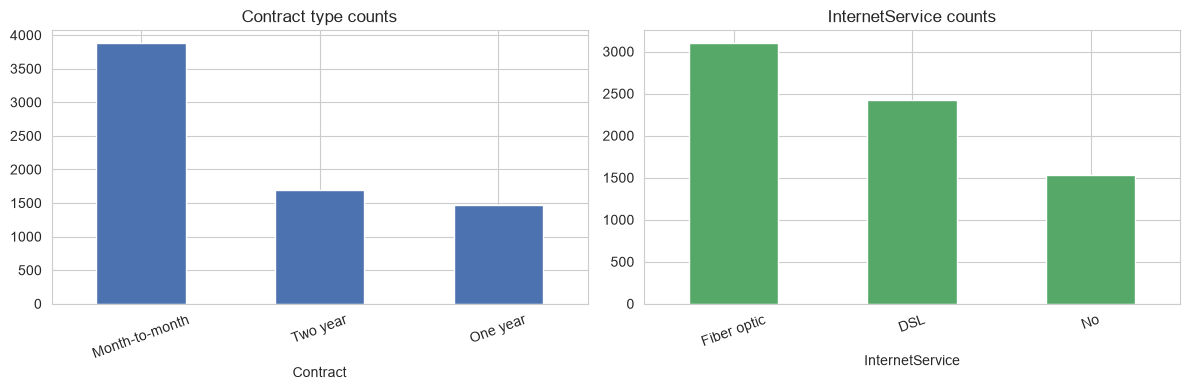

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean['Contract'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Contract type counts')
axes[0].tick_params(axis='x', rotation=20)
df_clean['InternetService'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('InternetService counts')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Task 12 (categorical) — interpretation**

Most customers are on a **month-to-month** contract, far more than one-year or two-year combined — this matters
a lot for churn since month-to-month customers face no penalty for leaving. For `InternetService`, **Fiber
optic** and **DSL** together dominate, with a smaller group having no internet service at all (phone-only
customers).

**Task 13 — outliers / skew in numerical features**

`TotalCharges` is right-skewed with a long tail toward high values (long-tenure customers who have paid a lot
cumulatively) and no real outliers beyond that natural skew — it's a cumulative sum, so this shape is expected.
`MonthlyCharges` doesn't show classic outliers either; its spread is wide because customers on very different
service tiers (phone-only vs. phone+fiber+streaming bundles) pay very different monthly amounts — the "outliers"
are really just a different customer segment, not data errors.

## Part 6 — Target Variable Analysis

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


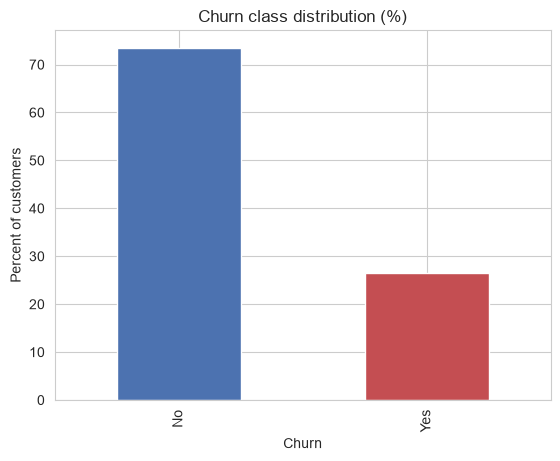

In [63]:
churn_counts = df_clean['Churn'].value_counts()
churn_pct = df_clean['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print()
print(churn_pct.round(2))

churn_pct.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Churn class distribution (%)')
plt.ylabel('Percent of customers')
plt.show()

**Task 14 — churned vs. non-churned**

Roughly **73–74% of customers did not churn** and about **26–27% did**, as shown above. That's a meaningfully
**imbalanced** target — not extreme (it's not 99/1), but "No" outnumbers "Yes" by close to 3-to-1.

**Task 15 — why the imbalance matters (not how to fix it)**

With this imbalance, a model can reach ~73% accuracy just by predicting "No" for every customer, which makes plain
accuracy a misleading way to judge a churn model — it would look "good" while never catching a single at-risk
customer. It also means the model naturally sees far fewer churn examples to learn the actual churn *pattern*
from, so it needs metrics (precision/recall/F1, ROC-AUC) and possibly a decision threshold that account for the
imbalance, since the real business cost of missing a churner is usually much higher than the cost of a false
alarm.

## Part 7 — Bivariate Analysis: Features vs. Churn

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


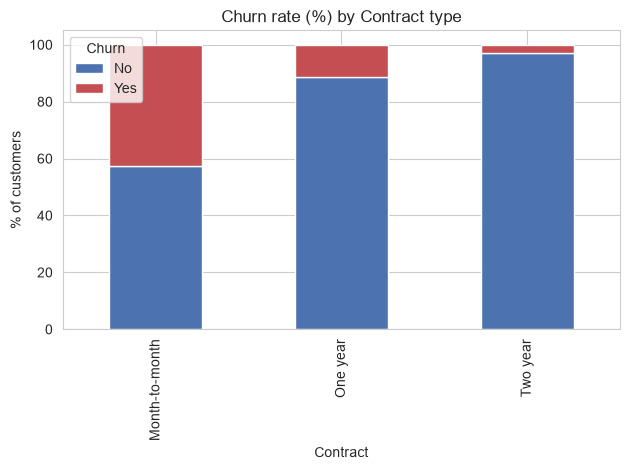

In [64]:
ct_contract = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
print(ct_contract.round(1))
ct_contract.plot(kind='bar', stacked=True, color=['#4C72B0', '#C44E52'])
plt.title('Churn rate (%) by Contract type')
plt.ylabel('% of customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Contract vs. Churn**
- **Observation:** Churn rate drops sharply as contract length increases.
- **Evidence:** Month-to-month customers churn at roughly 40%+, one-year contract customers around 10-12%, and two-year contract customers only around 2-3% (see table/chart above).
- **Possible explanation:** Longer contracts likely come with an early-termination cost or were chosen by customers who are already more committed, so both the incentive structure and the customer's mindset push churn down as contract length grows.

Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4


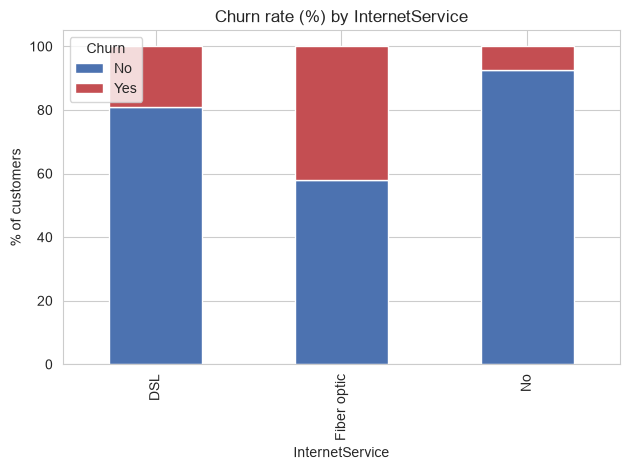

In [65]:
ct_internet = pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index') * 100
print(ct_internet.round(1))
ct_internet.plot(kind='bar', stacked=True, color=['#4C72B0', '#C44E52'])
plt.title('Churn rate (%) by InternetService')
plt.ylabel('% of customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**InternetService vs. Churn**
- **Observation:** Fiber optic customers churn noticeably more than DSL or no-internet customers.
- **Evidence:** Fiber optic churn is roughly 40%+, versus under 20% for DSL and under 10% for customers with no internet service at all.
- **Possible explanation:** Fiber is the priciest tier (consistent with the MonthlyCharges pattern below), so price sensitivity may play a role; it could also reflect service-quality or reliability complaints specific to the fiber product that push customers toward competitors.

/tmp/ipykernel_107735/529984840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_clean, ax=ax, palette=['#4C72B0', '#C44E52'])


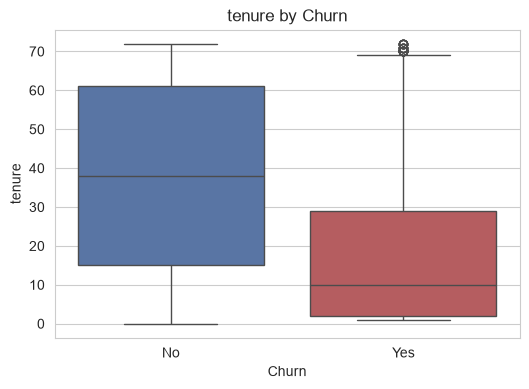

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


In [66]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df_clean, ax=ax, palette=['#4C72B0', '#C44E52'])
ax.set_title('tenure by Churn')
plt.show()
print(df_clean.groupby('Churn')['tenure'].median())

**tenure vs. Churn**
- **Observation:** Customers who churn tend to have much shorter tenure than those who stay.
- **Evidence:** The median tenure for churned customers is far lower than for retained customers (see boxplot and medians above) — churners cluster near the low end of the tenure range.
- **Possible explanation:** Risk of leaving is highest early in the relationship, before a customer has built up loyalty, habit, or sunk cost in the service — which lines up with the "bathtub" tenure distribution seen in Part 5.

/tmp/ipykernel_107735/2438922860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, ax=ax, palette=['#4C72B0', '#C44E52'])


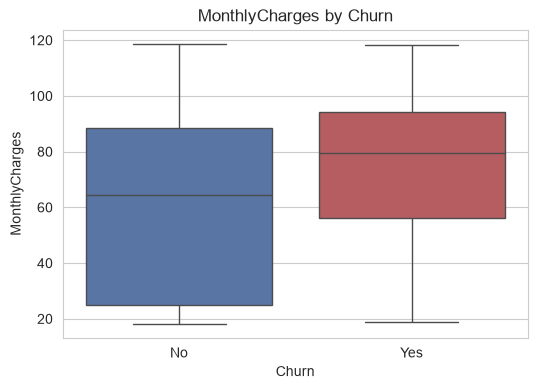

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


In [67]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, ax=ax, palette=['#4C72B0', '#C44E52'])
ax.set_title('MonthlyCharges by Churn')
plt.show()
print(df_clean.groupby('Churn')['MonthlyCharges'].median())

**MonthlyCharges vs. Churn**
- **Observation:** Customers who churn tend to pay more per month than customers who stay.
- **Evidence:** The median `MonthlyCharges` for churned customers is noticeably higher than for retained customers (see boxplot and medians above).
- **Possible explanation:** This lines up with the Fiber-optic finding — higher-paying customers are disproportionately on the pricier, higher-churn service tier, so price (or the value perceived for that price) looks like a real driver of churn rather than a coincidence.

## Part 8 — Correlation & Feature Relationships

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


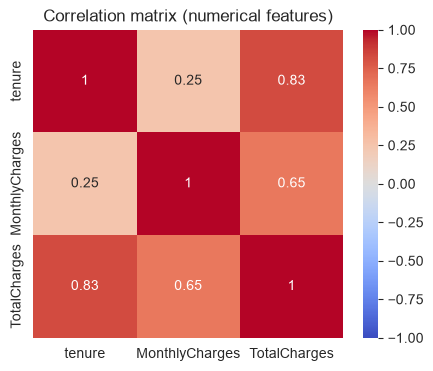

In [68]:
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df_clean[corr_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix (numerical features)')
plt.show()

**Task 18/19 — correlated pairs, and does correlation imply causation?**

`TotalCharges` is strongly correlated with both `tenure` (~0.83) and `MonthlyCharges` (~0.65) — which makes
complete sense mechanically, since `TotalCharges` is roughly `tenure × MonthlyCharges` accumulated over time; it
isn't an independent piece of information so much as a summary of the other two. `tenure` and `MonthlyCharges`
themselves are only weakly correlated (~0.25), so they do carry mostly separate information about a customer.

Correlation here does **not** imply causation — a long tenure doesn't *cause* high TotalCharges in the sense of
an external effect, it's definitionally built from it. The practical concern for modeling is **redundancy**: since
`TotalCharges` is almost a deterministic function of `tenure` and `MonthlyCharges`, including all three could
make a linear model unstable (multicollinearity) or just add noise without adding real predictive signal, so it's
worth considering dropping or combining one of them before Lab 3.

## Part 9 — Data Leakage Awareness

**Task 20 — leakage suspects**

- **`customerID`** — a pure identifier with no real predictive meaning; not leakage exactly, but it should never be used as a model input.
- **`TotalCharges`** — this is the one genuine leakage risk. It's the *cumulative* amount billed, which is mechanically tied to `tenure` and therefore partly encodes "how long this customer has already been a customer" — including how long they lasted *up to the point they churned*. Since it's built from the customer's full history (including time right up to churn), a model could lean on it as an indirect stand-in for the outcome itself rather than learning genuinely predictive patterns available *before* the churn decision.
- No column in this dataset is captured *after* the churn event itself (there's no "cancellation date" or "reason for leaving" field), so the main leakage risk here is this indirect encoding through `TotalCharges`/`tenure`, not a directly outcome-derived column.

**Task 21 — what goes wrong if such a column is left in**

If `TotalCharges` (or any feature that indirectly encodes the outcome) stays in the model's inputs, the model can
achieve artificially high accuracy during training/testing by exploiting that shortcut, but it won't actually be
learning the churn-risk *drivers* the business needs (contract type, service issues, pricing, etc.). Once deployed
on a genuinely new customer being scored *before* churn has happened, that shortcut signal won't be available in
the same way, and the model's real-world performance would collapse relative to what its evaluation metrics
promised.

## Part 10 — ML-Readiness Checklist

In [69]:
readiness = [
    ("customerID", "Identifier", "—", "Remove", "Unique per row, no predictive value"),
    ("gender", "Categorical", "Feature", "Keep (encode)", "Clean, no missing values; weak but valid candidate feature"),
    ("SeniorCitizen", "Numerical (0/1 flag)", "Feature", "Keep", "Already binary-encoded"),
    ("Partner", "Categorical", "Feature", "Keep (encode)", "Clean, may relate to household stability/churn"),
    ("Dependents", "Categorical", "Feature", "Keep (encode)", "Missing values filled with 'Unknown' category"),
    ("tenure", "Numerical", "Feature", "Keep", "Missing values median-filled; strong churn signal"),
    ("PhoneService", "Categorical", "Feature", "Keep (encode)", "Clean, defines service bundle"),
    ("MultipleLines", "Categorical", "Feature", "Keep (encode)", "Clean, defines service bundle"),
    ("InternetService", "Categorical", "Feature", "Keep (encode)", "Clean; strong churn signal (Fiber optic)"),
    ("OnlineSecurity", "Categorical", "Feature", "Keep (encode)", "Missing values filled with 'Unknown' category"),
    ("OnlineBackup", "Categorical", "Feature", "Keep (encode)", "Clean, add-on service"),
    ("DeviceProtection", "Categorical", "Feature", "Keep (encode)", "Clean, add-on service"),
    ("TechSupport", "Categorical", "Feature", "Keep (encode)", "Missing values filled with 'Unknown' category"),
    ("StreamingTV", "Categorical", "Feature", "Keep (encode)", "Clean, add-on service"),
    ("StreamingMovies", "Categorical", "Feature", "Keep (encode)", "Clean, add-on service"),
    ("Contract", "Categorical", "Feature", "Keep (encode)", "Clean; strongest churn signal found"),
    ("PaperlessBilling", "Categorical", "Feature", "Keep (encode)", "Clean, billing preference"),
    ("PaymentMethod", "Categorical", "Feature", "Keep (encode)", "Formatting standardized (case/whitespace), missing filled with 'Unknown'"),
    ("MonthlyCharges", "Numerical", "Feature", "Keep", "Missing values median-filled; correlates with churn"),
    ("TotalCharges", "Numerical", "Feature", "Keep with caution / consider dropping", "Converted to numeric; near-duplicate of tenure x MonthlyCharges — possible leakage/redundancy (see Part 9)"),
    ("Churn", "Categorical", "Target", "Keep", "The label to predict"),
]
readiness_df = pd.DataFrame(readiness, columns=["Column", "Type", "Role", "Action", "Reason"])
readiness_df

,Column,Type,Role,Action,Reason
0,customerID,Identifier,—,Remove,"Unique per row, no predictive value"
1,gender,Categorical,Feature,Keep (encode),"Clean, no missing values; weak but valid candi..."
2,SeniorCitizen,Numerical (0/1 flag),Feature,Keep,Already binary-encoded
3,Partner,Categorical,Feature,Keep (encode),"Clean, may relate to household stability/churn"
4,Dependents,Categorical,Feature,Keep (encode),Missing values filled with 'Unknown' category
5,tenure,Numerical,Feature,Keep,Missing values median-filled; strong churn signal
6,PhoneService,Categorical,Feature,Keep (encode),"Clean, defines service bundle"
7,MultipleLines,Categorical,Feature,Keep (encode),"Clean, defines service bundle"
8,InternetService,Categorical,Feature,Keep (encode),Clean; strong churn signal (Fiber optic)
9,OnlineSecurity,Categorical,Feature,Keep (encode),Missing values filled with 'Unknown' category


## Part 11 — Building the Clean Dataset

In [70]:
# Final clean_df for Lab 3: correct dtypes, missing values handled, duplicates handled,
# irrelevant identifier column removed.
clean_df = df_clean.drop(columns=['customerID']).copy()

print("Final clean_df shape:", clean_df.shape)
clean_df.to_csv("clean_churn.csv", index=False)
print("Saved to clean_churn.csv")

Final clean_df shape: (7043, 20)
Saved to clean_churn.csv


In [71]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

## Part 12 — Key Findings & Final Reflection

**Five Key Findings**

**Finding 1**
- Observation: Contract type is the single strongest churn signal found in this dataset.
- Evidence: Month-to-month churn (~40%+) is roughly 4x one-year churn and ~15x two-year churn.
- Interpretation: Retention efforts (e.g. incentives to move customers onto longer contracts) likely have outsized impact compared to almost any other lever in this data.

**Finding 2**
- Observation: Fiber optic internet customers churn much more than DSL or no-internet customers.
- Evidence: Fiber churn (~40%+) vs. DSL (~19%) vs. no internet (~7%).
- Interpretation: Either the price of fiber or its service quality is driving dissatisfaction; worth a follow-up investigation the business can act on directly (pricing tiers or service reliability).

**Finding 3**
- Observation: New customers are far more likely to churn than long-tenured ones.
- Evidence: Median tenure for churners is much lower than for retained customers; the raw tenure distribution shows a spike near 0 months.
- Interpretation: The first several months of the customer relationship are the highest-risk window — an onboarding/early-engagement program could meaningfully reduce churn.

**Finding 4**
- Observation: `TotalCharges` is almost entirely redundant with `tenure` and `MonthlyCharges` (correlation ~0.83 with tenure, ~0.65 with MonthlyCharges).
- Evidence: Correlation matrix in Part 8.
- Interpretation: This column carries real leakage/redundancy risk and needs a deliberate decision (drop, or engineer into a ratio feature) before Lab 3's modeling step.

**Finding 5**
- Observation: The data-quality issues in this dataset (missing values, duplicate customerIDs with updated values, inconsistent `PaymentMethod` formatting, blank `TotalCharges` for brand-new customers) were all explainable rather than random noise.
- Evidence: Every blank `TotalCharges` row had `tenure == 0`; duplicate customerIDs had internally consistent but updated tenure/charges; formatting inconsistencies were purely cosmetic (case/whitespace).
- Interpretation: Understanding *why* a data-quality issue exists, not just patching it mechanically, is what made each cleaning decision in Part 4 justifiable rather than arbitrary.

**Final Reflection**

- **Most important data-quality issue:** The `TotalCharges` column being stored as text with blank values for brand-new customers — it silently breaks any numeric analysis until you notice and fix the dtype.
- **Most interesting pattern:** How strongly `Contract` type predicts churn on its own — a single categorical column explains a huge share of the churn/no-churn split.
- **Feature most useful for predicting churn:** `Contract`, closely followed by `tenure` and `InternetService`.
- **Feature that should probably not be used:** `customerID` (no predictive value) and `TotalCharges` should be used cautiously given its redundancy with `tenure`/`MonthlyCharges`.
- **Preprocessing still needed before ML modeling (conceptually):** Encoding all the categorical columns (e.g. one-hot encoding), scaling the numerical columns for distance-based models, deciding how to handle the `TotalCharges` redundancy, and a train/test split that respects the class imbalance (e.g. stratified split).
- **What I'd do with 3 more hours:** Dig into interaction effects — e.g. does the fiber-optic churn spike hold up within every contract type, or is it really just a month-to-month effect in disguise — and engineer a couple of candidate features (like an `AvgMonthlySpend = TotalCharges / tenure` ratio) to reduce the `TotalCharges` redundancy issue found in Part 8.